In [1]:
import pandas, matplotlib_venn, supervenn
import csv
from itertools import zip_longest

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 'font.family':'sans-serif', 'xtick.labelsize':30, 'ytick.labelsize':30, 'figure.figsize':(16, 9), 'axes.labelsize':40, 'svg.fonttype':'none'})

In [3]:
degs_dir = '/Users/adrian/research/bmcbf/073_bologna/results/degs/'

In [4]:
label = 'effect_timepoint_D7_vs_D0.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d7_d0 = set(df.index)

label = 'effect_timepoint_D21_vs_D7.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d21_d7 = set(df.index)

label = 'effect_timepoint_D28_vs_D21.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d28_d21 = set(df.index)

label = 'effect_timepoint_D28_vs_D7.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d28_d7 = set(df.index)

label = 'effect_timepoint_D35_vs_D28.responders.tsv'
df = pandas.read_csv(degs_dir + label, sep='\t')
d35_d28 = set(df.index)

print(len(d7_d0), len(d21_d7), len(d28_d21), len(d28_d7), len(d35_d28))

1714 449 40 772 72


961
1452 262 699


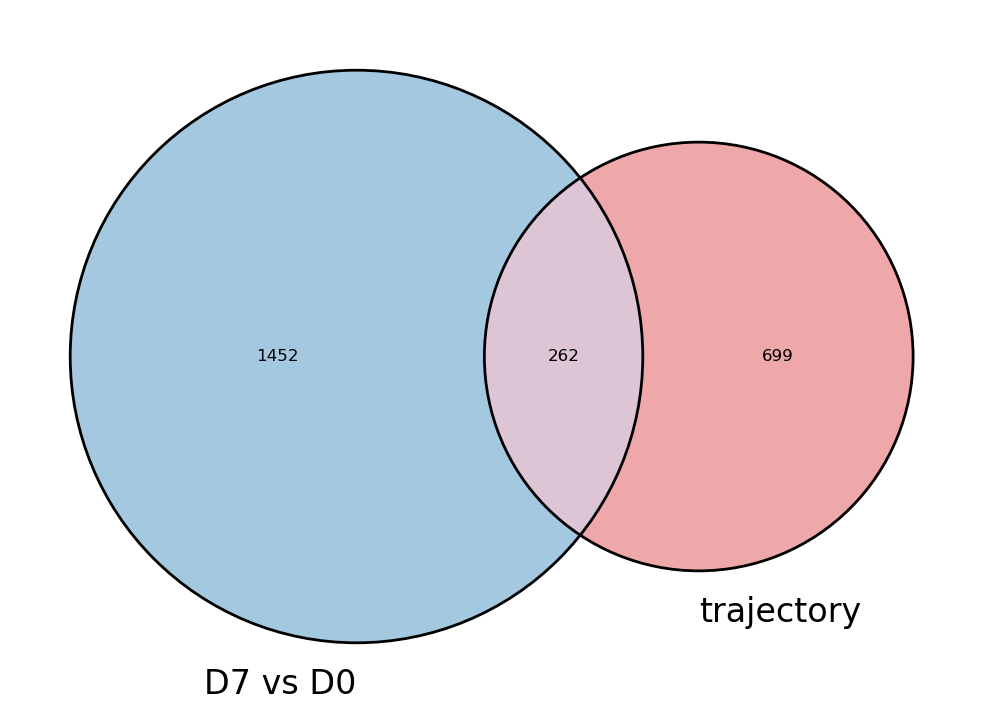

In [5]:
# get the genes that change during trajectory
# get the genes that are specific of early response to trajectory
trajectory = d21_d7 | d28_d21 | d28_d7
print(len(trajectory))

sets = [d7_d0, trajectory]
labels = ['D7 vs D0', 'trajectory']

v = matplotlib_venn.venn2(
    subsets=sets,
    set_labels = labels,
    set_colors=("tab:blue", "tab:red"),
)

matplotlib_venn.venn2_circles(
    subsets=sets,
    lw=2
)
for text in v.set_labels:
    text.set_fontsize(24)
for x in range(len(v.subset_labels)):
    if v.subset_labels[x] is not None:
        v.subset_labels[x].set_fontsize(12)

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('venn1.svg')

# storing the particular elements
left = d7_d0 - trajectory
middle = d7_d0 & trajectory
right = trajectory - d7_d0
print(len(left), len(middle), len(right))

with open('/Users/adrian/research/bmcbf/073_bologna/results/degs/first_sets.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['left', 'middle', 'right'])
    for row in zip_longest(sorted(left), sorted(middle), sorted(right), fillvalue=''):
        writer.writerow(row)

181 268 512


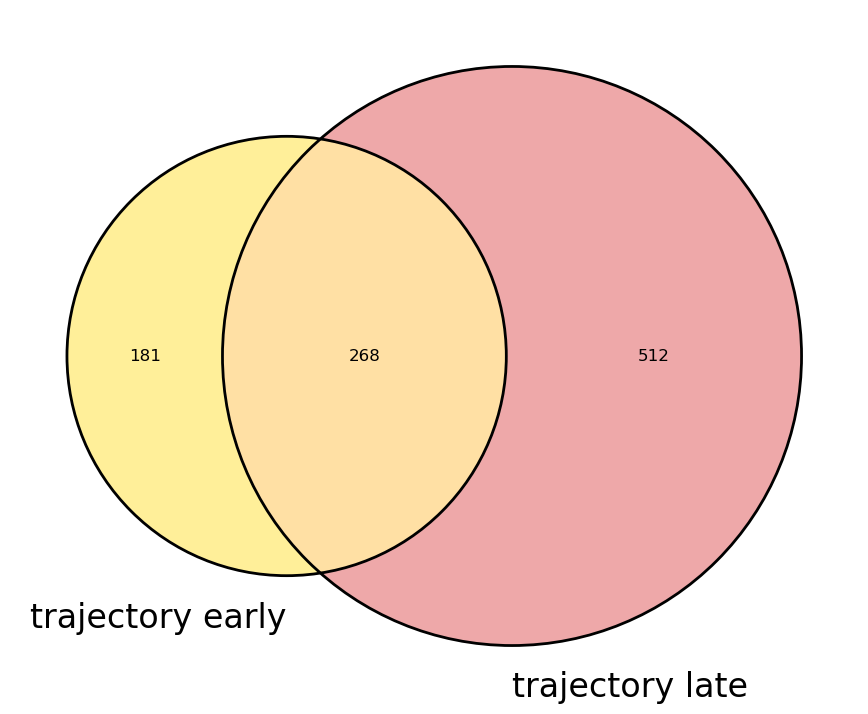

In [6]:
# within trajectory get early and late genes
trajectory_late = d28_d21 | d28_d7
sets = [d21_d7, trajectory_late]

labels = ['trajectory early', 'trajectory late']

v = matplotlib_venn.venn2(
    subsets=sets,
    set_labels = labels,
    set_colors=("gold", "tab:red"),
)

matplotlib_venn.venn2_circles(
    subsets=sets,
    lw=2
)
for text in v.set_labels:
    text.set_fontsize(24)
for x in range(len(v.subset_labels)):
    if v.subset_labels[x] is not None:
        v.subset_labels[x].set_fontsize(12)

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('venn2.svg')

# storing the particular elements
left = d21_d7 - trajectory_late
middle = d21_d7 & trajectory_late
right = trajectory_late - d21_d7
print(len(left), len(middle), len(right))

with open('/Users/adrian/research/bmcbf/073_bologna/results/degs/second_sets.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['left', 'middle', 'right'])
    for row in zip_longest(sorted(left), sorted(middle), sorted(right), fillvalue=''):
        writer.writerow(row)